In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load file
file = r"D:\CA_251090050530\Northwind.xlsx"

# Load all sheets
xls = pd.ExcelFile(file)

# 1. Explore all tables
print("Available Tables:", xls.sheet_names)

for sheet in xls.sheet_names:
    df = pd.read_excel(file, sheet_name=sheet)
    print(f"\n--- {sheet} ---")
    print(df.head())


# Load required tables
orders = pd.read_excel(file, sheet_name='Orders')
order_details = pd.read_excel(file, sheet_name='Order Details')
products = pd.read_excel(file, sheet_name='Products')
categories = pd.read_excel(file, sheet_name='Categories')
customers = pd.read_excel(file, sheet_name='Customers')
employees = pd.read_excel(file, sheet_name='Employees')

Available Tables: ['Categories', 'Customers', 'Employees', 'Order Details', 'Orders', 'Products']

--- Categories ---
   CategoryID    CategoryName  \
0           1       Beverages   
1           2      Condiments   
2           3     Confections   
3           4  Dairy Products   
4           5  Grains/Cereals   

                                         Description  
0        Soft drinks, coffees, teas, beers, and ales  
1  Sweet and savory sauces, relishes, spreads, an...  
2                Desserts, candies, and sweet breads  
3                                            Cheeses  
4                Breads, crackers, pasta, and cereal  

--- Customers ---
  CustomerID                         CompanyName         ContactName  \
0      ALFKI                  Alfred Futterkiste        Maria Anders   
1      ANATR  Ana Trujillo Emparedados y helados        Ana Trujillo   
2      ANTON             Antonio Moreno Taquería      Antonio Moreno   
3      AROUT                     Around the Ho

In [ ]:
# 2a. Total Sales per Product
order_details['Sales'] = order_details['UnitPrice'] * order_details['Quantity'] * (1 - order_details['Discount'])

sales_product = order_details.merge(products, on='ProductID')
total_sales_product = sales_product.groupby('ProductName')['Sales'].sum()

print("\nTotal Sales per Product:")
print(total_sales_product.sort_values(ascending=False))


# 2b. Total Sales per Category
sales_category = sales_product.merge(categories, on='CategoryID')
total_sales_category = sales_category.groupby('CategoryName')['Sales'].sum()

print("\nTotal Sales per Category:")
print(total_sales_category)


Total Sales per Product:
ProductName
Côte de Blaye                141396.734903
Thüringer Rostbratwurst       80368.671975
Raclette Courdavault          71155.699909
Tarte au sucre                47234.969954
Camembert Pierrot             46825.479953
                                 ...      
Longlife Tofu                  2432.499999
Laughing Lumberjack Lager      2396.799996
Genen Shouyu                   1784.825000
Geitost                        1648.124999
Chocolade                      1368.712494
Name: Sales, Length: 77, dtype: float64

Total Sales per Category:
CategoryName
Beverages         267868.179744
Condiments        106047.084879
Confections       167357.224843
Dairy Products    234507.284742
Grains/Cereals     95744.587428
Meat/Poultry      163022.359392
Produce            99984.579916
Seafood           131261.737345
Name: Sales, dtype: float64


In [ ]:
# 3. Top 5 Customers by Revenue
customer_sales = sales_product.merge(orders, on='OrderID')
customer_sales = customer_sales.merge(customers, on='CustomerID')

top_customers = customer_sales.groupby('CompanyName')['Sales'].sum().sort_values(ascending=False).head(5)

print("\nTop 5 Customers:")
print(top_customers)


Top 5 Customers:
CompanyName
QUICK-Stop                      110277.304884
Ernst Handel                    104874.978354
Save-a-lot Markets              104361.949868
Rattlesnake Canyon Grocery       51097.800488
Hungry Owl All-Night Grocers     49979.904946
Name: Sales, dtype: float64


In [ ]:
# 4. Total Orders by Country
orders_country = orders.merge(customers, on='CustomerID')
orders_per_country = orders_country.groupby('Country')['OrderID'].count()

print("\nOrders per Country:")
print(orders_per_country)


Orders per Country:
Country
Argentina       16
Austria         40
Belgium         19
Brazil          83
Canada          30
Denmark         18
Finland         22
France          77
Germany        122
Ireland         19
Italy           28
Mexico          28
Norway           6
Poland           7
Portugal        13
Spain           23
Sweden          37
Switzerland     18
UK              56
USA            122
Venezuela       46
Name: OrderID, dtype: int64


In [ ]:
# 5. Monthly Sales Trend
orders['OrderDate'] = pd.to_datetime(orders['OrderDate'])

monthly_sales = customer_sales.copy()
monthly_sales['Month'] = monthly_sales['OrderDate'].dt.to_period('M')

monthly_trend = monthly_sales.groupby('Month')['Sales'].sum()

print("\nMonthly Sales Trend:")
print(monthly_trend)


Monthly Sales Trend:
Month
1996-07     27861.894957
1996-08     25485.274987
1996-09     26381.399988
1996-10     37515.724914
1996-11     45600.044943
1996-12     45239.629965
1997-01     61258.069930
1997-02     38483.634943
1997-03     38547.219970
1997-04     53032.952427
1997-05     53781.289928
1997-06     36362.802448
1997-07     51020.857453
1997-08     47287.669948
1997-09     55629.242457
1997-10     66749.225952
1997-11     43533.808967
1997-12     71398.428447
1998-01     94222.110383
1998-02     99415.287456
1998-03    104854.154938
1998-04    123798.682421
1998-05     18333.630465
Freq: M, Name: Sales, dtype: float64


In [ ]:
# 6. Average Order Value per Employee
employee_sales = customer_sales.merge(employees, on='EmployeeID')
avg_order_value = employee_sales.groupby('EmployeeID')['Sales'].mean()

print("\nAverage Order Value per Employee:")
print(avg_order_value)


Average Order Value per Employee:
EmployeeID
1    556.833636
2    691.028028
3    631.815710
4    554.502014
5    587.968226
6    439.959104
7    707.774061
8    487.931836
9    722.505293
Name: Sales, dtype: float64


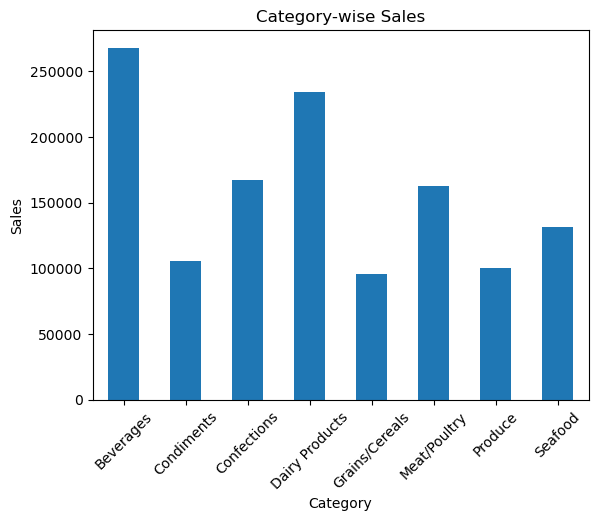

In [ ]:
# 7. Bar Chart: Category-wise Sales
total_sales_category.plot(kind='bar')
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()




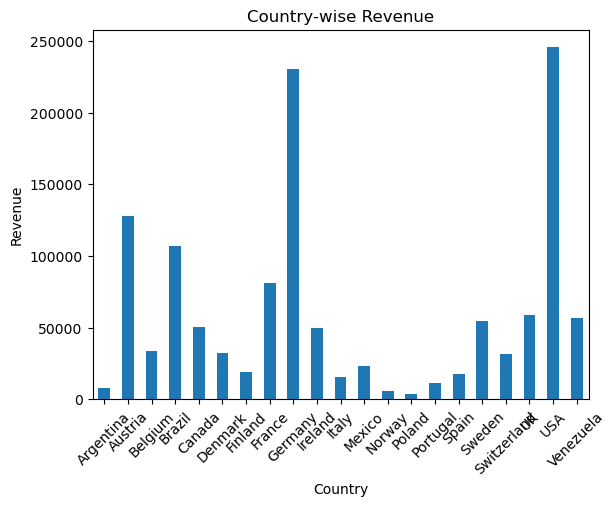

In [ ]:
# 8. Country-wise Revenue Contribution
country_revenue = customer_sales.groupby('Country')['Sales'].sum()

country_revenue.plot(kind='bar')
plt.title("Country-wise Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()